# Classifição de Animais - Animals-10

**Este notebook tem como objetivo criar um modelo de classificação utilizando** 
- Data augmentation 
- Pipeline eficiente com `ImageDataGenerator` (Sem carregar tudo na RAM)
- Treinamento com duas fases com fine-tuning
- EarlyStopping e ReduceOnPlateau para controle do treino

## Importações

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization, Input
from tensorflow.keras import Sequential
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import numpy as np

C:\Users\adrie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## Parametros básicos 

In [19]:
# Dimensões das imagens e tamanho do batch
img_height = 224
img_width = 224
batch = 32

## Organizando o Dataset

Usamos o `ImageDataGenerator` para carregar as imagens diretamente das pastas, sem precisar colocar tudo na memória RAM de uma vez.  

Aplicamos  **data augmentations** apenas no conjunto de imagens de treino para aumentar a variedade do dataset e reduzir overfitting

In [20]:
#gerador de imagens com data augmentation
data_augmentation_generator = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,         #Processo de normalização, reduzindo os valores dos pixels de 0-255 para 0-1 aumentando a performance
    validation_split=0.2,   #Reserva 20% das imagens geradas para realizar a validação da epóca
    rotation_range=20,      #Rotaciona as imagens em até 20 graus em direção aleatória
    width_shift_range=0.1,  #Desloca horizontalmente em até 10%
    height_shift_range=0.1, #Desloca verticalmente em até 10%
    horizontal_flip=True,   #Espelhamento horizontal
    zoom_range=0.1          #zoom de até 10%
)

#gerador de imagens sem data augmentation para validação
validation_generator = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

#carregando as imagens de treino usando a variável de data augmentation
training_data = data_augmentation_generator.flow_from_directory(
    'raw-img',
    target_size=(img_height,img_width),
    batch_size=batch,
    class_mode='sparse',
    subset='training',
    seed=42
)

#carregando as imagens de treino usando a variável de validacao
validation_data = validation_generator.flow_from_directory(
    'raw-img',
    target_size=(img_height,img_width),
    batch_size=batch,
    class_mode='sparse',
    subset='validation',
    seed=42
)

#Exibe as classes encontradas e seus indices
print("Classes encontradas: ",training_data.class_indices)

Found 20947 images belonging to 10 classes.
Found 5232 images belonging to 10 classes.
Classes encontradas:  {'butterfly': 0, 'cat': 1, 'chicken': 2, 'cow': 3, 'dog': 4, 'elephant': 5, 'horse': 6, 'sheep': 7, 'spider': 8, 'squirrel': 9}


## Criando o modelo

Estamos criando um modelo CNN do zero montando cada camada até a classificação

In [22]:
#criando o modelo sequencial e suas camadas
model = Sequential([

    #Bloco 1 -> Camada de entrada
    Input(shape=(img_height,img_width,3)),              # altura, largura e canais de cores (RGB = 3)
    Conv2D(32,(3,3),activation='relu', padding='same'),  # entrada: (224x224); filtros: (32);  saída: (224x224x32)
    BatchNormalization(),
    Conv2D(32,(3,3),activation='relu', padding='same'),  # entrada: (224x224); filtros: (32);  saída: (224x224x32)
    MaxPooling2D((2,2)),                                # reduz pela metade mantendo as principais features -> (112x112x32)
    Dropout(0.25),

    #Bloco 2
    Conv2D(64,(3,3),activation='relu', padding='same'),  # entrada: (112x112x32); filtros: (64);  saída: (112x112x64)
    BatchNormalization(),
    Conv2D(64,(3,3),activation='relu', padding='same'),  # entrada: (112x112x32); filtros: (64);  saída: (112x112x64)
    MaxPooling2D((2,2)),                                # reduz pela metade mantendo as principais features -> (56x56x64)
    Dropout(0.25),

    #Bloco 3
    Conv2D(128,(3,3),activation='relu', padding='same'), # entrada: (56x56x64); filtros: (128);  saída: (56x56x128)
    BatchNormalization(),
    Conv2D(128,(3,3),activation='relu', padding='same'), # entrada: (56x56x64); filtros: (128);  saída: (56x56x128)
    MaxPooling2D((2,2)),                                # reduz pela metade mantendo as principais features -> (28x28x64)
    Dropout(0.25),

    #Bloco 4
    Conv2D(256,(3,3),activation='relu', padding='same'), # entrada: (28x28x128); filtros: (256);  saída: (28x28x256)
    BatchNormalization(),                               # reduz pela metade mantendo as principais features -> (14x14x256)
    MaxPooling2D((2,2)),
    Dropout(0.25),

    #Classificador
    Flatten(),                                          # Camada que achata a matriz de entrada para um vetor
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')                     # Classifica a imagem
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 13,433,002 (51.24 MB)

 Trainable params: 13,431,530 (51.24 MB)

 Non-trainable params: 1,472 (5.75 KB)

## Treinando o Modelo

Nessa fase
- Criamos as variaveis de Callback (EarlyStopping, ReduceOnPlateau)
- Compilamos o modelo
- Treinamos o modelo

In [23]:
#Criando o Callback
callbacks=[
    EarlyStopping(patience=10, restore_best_weights=True),  # Se não houver melhora no loss em 10 épocas, restaura o ultimo melhor resultado
    ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6)  # Se não houver melhora no loss em 5 épocas, diminui o learning rate
]

#Compilando o modelo 
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Treinando o modelo e armazenando o histórico para avaliações 
hist = model.fit(
    training_data,                      # dados de treinamento e suas classificações 
    epochs=50,                          # número máximo de épocas
    validation_data=validation_data,    # dados de validação 
    callbacks=callbacks                 #callbacks
)

Epoch 1/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 616s 937ms/step - accuracy: 0.3214 - loss: 2.1280 - val_accuracy: 0.4352 - val_loss: 1.5882 - learning_rate: 0.0010
Epoch 2/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 605s 923ms/step - accuracy: 0.4751 - loss: 1.5589 - val_accuracy: 0.5013 - val_loss: 1.4790 - learning_rate: 0.0010
Epoch 3/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 606s 925ms/step - accuracy: 0.5409 - loss: 1.3482 - val_accuracy: 0.5247 - val_loss: 1.4035 - learning_rate: 0.0010
Epoch 4/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 607s 926ms/step - accuracy: 0.5889 - loss: 1.2146 - val_accuracy: 0.4037 - val_loss: 1.8475 - learning_rate: 0.0010
Epoch 5/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 606s 925ms/step - accuracy: 0.6107 - loss: 1.1524 - val_accuracy: 0.5621 - val_loss: 1.3120 - learning_rate: 0.0010
Epoch 6/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 607s 927ms/step - accuracy: 0.6520 - loss: 1.0224 - val_accuracy: 0.6676 - val_loss: 0.9583 - learning_rate: 0.0010
Epoch 7/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 607s 927ms/step - accura

## Avaliando os resultados

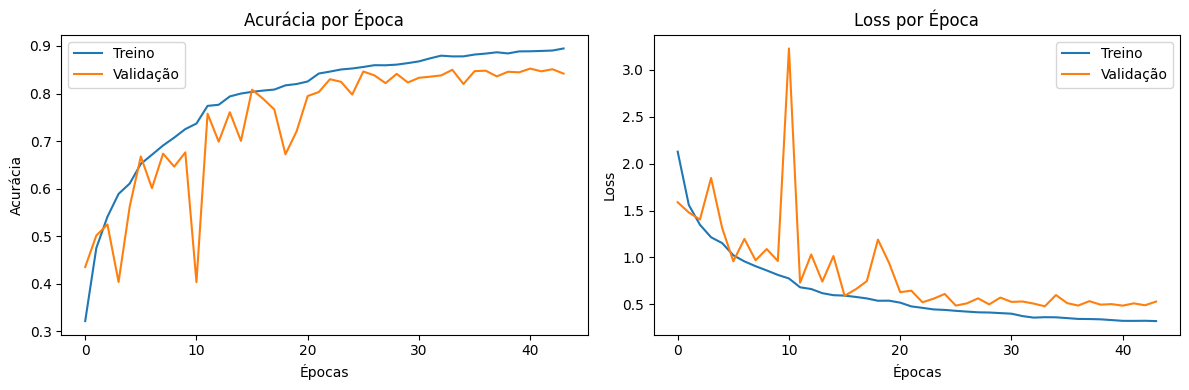

In [26]:

#Plota as curvas de acurácia e loss do treino e validação
plt.figure(figsize=(12, 4))

# Gráfico de acurácia
plt.subplot(1, 2, 1)
plt.plot(hist.history['accuracy'], label='Treino')
plt.plot(hist.history['val_accuracy'], label='Validação')
plt.title('Acurácia por Época')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()

# Gráfico de loss
plt.subplot(1, 2, 2)
plt.plot(hist.history['loss'], label='Treino')
plt.plot(hist.history['val_loss'], label='Validação')
plt.title(f'Loss por Época')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


## Avaliação Final no Conjunto de Teste

In [24]:
# Avaliando o modelo nos dados de validação
loss_final, acuracia_final = model.evaluate(validation_data)
print(f"\nLoss final: {loss_final:.4f}")
print(f"Acurácia final: {acuracia_final*100:.2f}%")

164/164 ━━━━━━━━━━━━━━━━━━━━ 32s 196ms/step - accuracy: 0.8500 - loss: 0.4783

Loss final: 0.4783
Acurácia final: 85.00%


## Salvando o modelo

In [25]:
model.save('animal_classification.keras')

## Testando o modelo salvo com imagem que não está presente no treino

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Categoria: Squirrel
Confiabilidade: 98.2609%


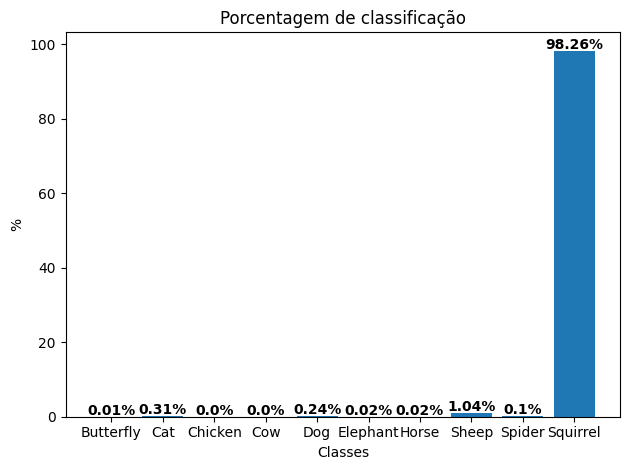

In [30]:
#carregando o modelo
saved_model = load_model('animal_classification.keras')

#Funcao que normaliza a imagem e testa no modelo
def predict_image(img_path, model, width=224, height=224):                          # Neste caso definimos as dimensoes das imagens com valores padroes referentes ao modelo que treinamos anteriormente, caso seu modelo tenha sido treinado com outras dimensoes basta alterar a entrada destes valores
    img = keras.preprocessing.image.load_img(img_path,target_size=(width,height))   # Procura a imagem e deixa no tamanho da entrada esperado
    img_array = keras.preprocessing.image.img_to_array(img) / 255.0                 # Normaliza os valores dos canais de cor transformando em um array  
    img_array = np.expand_dims(img_array, axis=0)                                   

    prediction = model.predict(img_array)                                           # tabela com probabilidades de resultados
    class_idx = np.argmax(prediction)                                               # Numero do indice do valor mais provavel
    reliability = prediction[0][class_idx] * 100                                    # Porcentagem do valor mais provavel

    prediction_array_percentage = []
    for i in range(len(prediction[0])):                                             #acessa a array de predict com todos os valores
        percentage = round(float(prediction[0][i]*100),2)                           #arredonda e passa para ponto flutuante
        prediction_array_percentage.append(percentage)                              #adiciona em um array as porcentagens arredondadas

    return {
        0: prediction_array_percentage,
        1: class_idx,
        2: reliability}


prediction = predict_image('some_tests/squirrel.jpg', saved_model)
labels = ['Butterfly', 'Cat', 'Chicken', 'Cow', 'Dog', 'Elephant', 'Horse', 'Sheep', 'Spider', 'Squirrel']

print(f'Categoria: {labels[prediction[1]]}')
print(f'Confiabilidade: {prediction[2]:.4f}%')


#Grafico de barras indicando a porcentagem de cada classificacao
plt.bar(labels, prediction[0])
for i, v in enumerate(prediction[0]):
    plt.text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')
plt.title('Porcentagem de classificação')
plt.xlabel('Classes')
plt.ylabel('%')
plt.tight_layout()
plt.show()

